In [1]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [2]:
dataset_path = "/kaggle/input/datasets/mustakimbinmohsin/industrial-fabric-defect-detection/Fabric_Dataset"
image_pipeline = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])
train_dataset = datasets.ImageFolder(
    root = os.path.join(dataset_path,"train/"),
    transform = image_pipeline
)
test_dataset = datasets.ImageFolder(
    root = os.path.join(dataset_path,"test/"),
    transform = image_pipeline
)

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)


print(f"Total Training Images: {len(train_dataset)}")
print(f"Total Test Dataset: {len(test_dataset)}")
print(f"Classes found: {train_dataset.classes}")
print(f"Classes found: {test_dataset.classes}")



Total Training Images: 3698
Total Test Dataset: 1141
Classes found: ['good']
Classes found: ['anomaly', 'good']


Device: cuda
Input shape  : torch.Size([2, 3, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])
Params       : 4,359,587

Training exclusively on 'good' images : 3698 samples

  Training Convolutional Autoencoder
  Epochs: 50  |  LR: 0.001  |  Device: cuda

  Epoch [  1/50]  Loss: 0.032352  LR: 9.99e-04  ← best
  Epoch [  5/50]  Loss: 0.007605  LR: 9.76e-04  ← best
  Epoch [ 10/50]  Loss: 0.006455  LR: 9.05e-04  
  Epoch [ 15/50]  Loss: 0.006051  LR: 7.96e-04  
  Epoch [ 20/50]  Loss: 0.005839  LR: 6.58e-04  
  Epoch [ 25/50]  Loss: 0.005565  LR: 5.05e-04  ← best
  Epoch [ 30/50]  Loss: 0.005639  LR: 3.52e-04  
  Epoch [ 35/50]  Loss: 0.005860  LR: 2.14e-04  
  Epoch [ 40/50]  Loss: 0.005454  LR: 1.05e-04  
  Epoch [ 45/50]  Loss: 0.005314  LR: 3.42e-05  ← best
  Epoch [ 50/50]  Loss: 0.005289  LR: 1.00e-05  

  Training complete. Best loss: 0.005278
  Checkpoint saved → /kaggle/working/autoencoder_best.pth



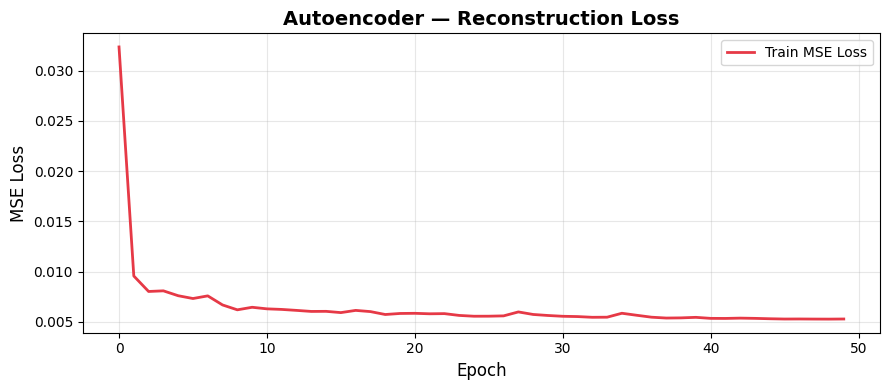

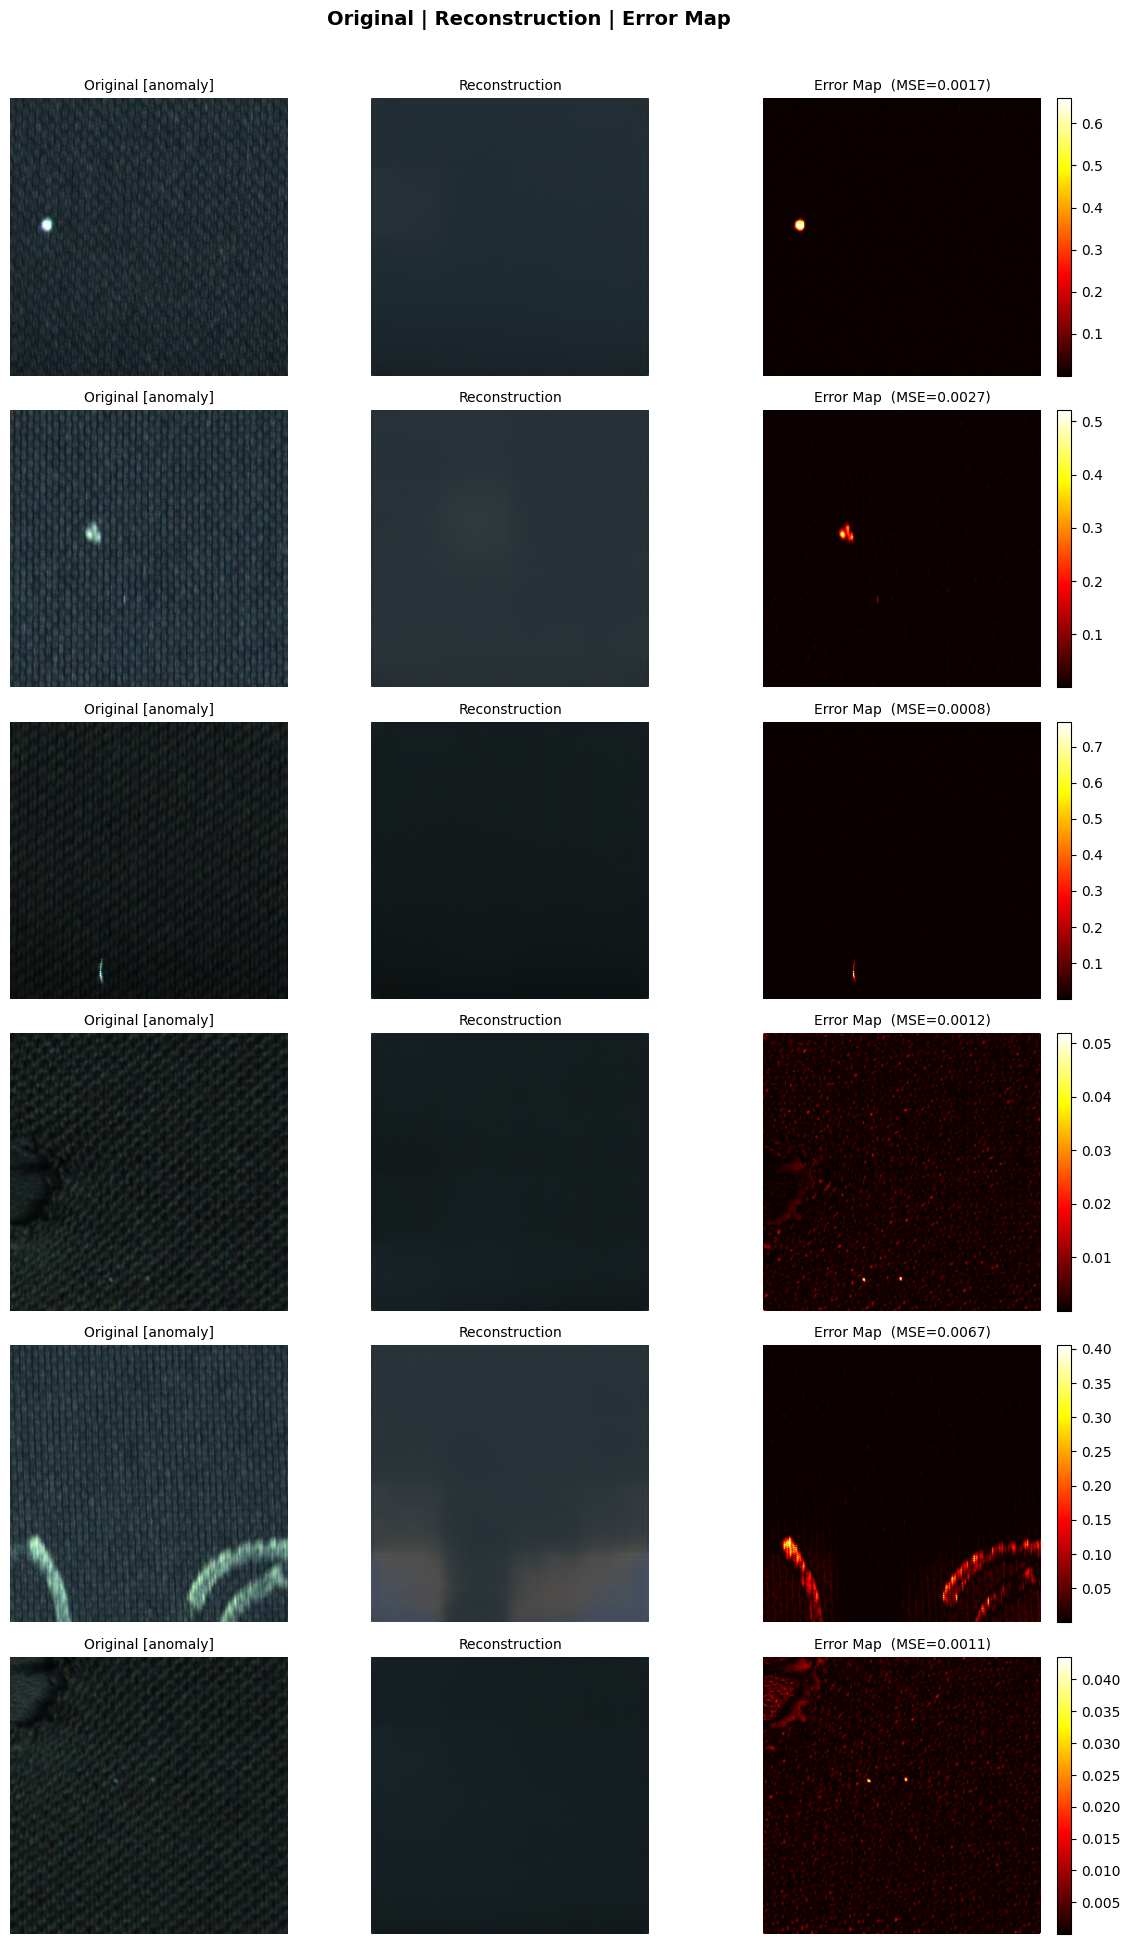

In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super(ConvAutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # 256->128
            nn.Conv2d(3,32, kernel_size =3, stride = 2 , padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),

            # 128 -> 64
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (B,64,64,64)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 -> 32
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (B,128,32,32)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 32 -> 16
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# (B,256,16,16)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 16 -> 8
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),# (B,256,8,8)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 8 -> 4  (bottleneck)
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),# (B,256,4,4)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1), # (B,256,8,8)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 8 → 16
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1), # (B,256,16,16)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 16 → 32
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # (B,128,32,32)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 32 → 64
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # (B,64,64,64)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 → 128
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # (B,32,128,128)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 128 → 256  (output)
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # (B,3,256,256)
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def encode(self, x):
        return self.encoder(x)


# Quick sanity-check
_model = ConvAutoEncoder()
_dummy = torch.randn(2, 3, 256, 256)
_out   = _model(_dummy)
print(f"Input shape  : {_dummy.shape}")
print(f"Output shape : {_out.shape}")
print(f"Params       : {sum(p.numel() for p in _model.parameters()):,}")
del _model, _dummy, _out

print(f"\nTraining exclusively on 'good' images : {len(train_dataset)} samples")


# ============================================================
# 2.3  LOSS FUNCTION
# ============================================================
# MSE is standard for pixel-level reconstruction.
# SSIM can be added later for perceptual quality.
# ============================================================

reconstruction_loss = nn.MSELoss()


# ============================================================
# 2.4  TRAINING SETUP
# ============================================================

def train_autoencoder(
    model,
    train_loader,
    num_epochs   = 50,
    learning_rate = 1e-3,
    weight_decay  = 1e-5,
    save_path     = "/kaggle/working/autoencoder_best.pth",
):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Cosine annealing — smoother convergence, no manual LR tuning
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    history = {"train_loss": []}
    best_loss = float("inf")

    print(f"\n{'='*55}")
    print(f"  Training Convolutional Autoencoder")
    print(f"  Epochs: {num_epochs}  |  LR: {learning_rate}  |  Device: {device}")
    print(f"{'='*55}\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0

        for batch_imgs, _ in train_loader:
            batch_imgs = batch_imgs.to(device)

            # Forward
            reconstructed = model(batch_imgs)
            loss = reconstruction_loss(reconstructed, batch_imgs)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_imgs.size(0)

        scheduler.step()

        avg_loss = epoch_loss / len(train_loader.dataset)
        history["train_loss"].append(avg_loss)

        # Save best checkpoint
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>3}/{num_epochs}]  Loss: {avg_loss:.6f}  "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}  "
                  f"{'← best' if avg_loss == best_loss else ''}")

    print(f"\n  Training complete. Best loss: {best_loss:.6f}")
    print(f"  Checkpoint saved → {save_path}\n")
    return model, history


# ============================================================
# 2.5  TRAIN
# ============================================================

autoencoder = ConvAutoEncoder()
autoencoder, history = train_autoencoder(
    model        = autoencoder,
    train_loader = train_dataloader,
    num_epochs   = 50,
    learning_rate = 1e-3,
)


# ============================================================
# 2.6  TRAINING CURVE
# ============================================================

def plot_training_curve(history):
    plt.figure(figsize=(9, 4))
    plt.plot(history["train_loss"], linewidth=2, color="#E63946", label="Train MSE Loss")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.title("Autoencoder — Reconstruction Loss", fontsize=14, fontweight="bold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curve.png", dpi=150)
    plt.show()

plot_training_curve(history)


# ============================================================
# 2.7  VISUAL SANITY CHECK — Good vs Anomaly Reconstruction
# ============================================================

def visualize_reconstructions(model, test_loader, n=6):
    """
    Side-by-side: Original | Reconstruction | Error Map
    for the first n images in the test set.
    """
    model.eval()
    model.to(device)

    imgs, labels = next(iter(test_loader))
    imgs = imgs.to(device)

    with torch.no_grad():
        recons = model(imgs)

    # Error map (per-pixel MSE, averaged across channels)
    error_maps = ((imgs - recons) ** 2).mean(dim=1).cpu().numpy()

    imgs   = imgs.cpu().numpy().transpose(0, 2, 3, 1)
    recons = recons.cpu().numpy().transpose(0, 2, 3, 1)
    labels = labels.numpy()

    class_names = test_dataset.classes  # ['anomaly', 'good']

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3.2))
    fig.suptitle("Original | Reconstruction | Error Map", fontsize=14, fontweight="bold", y=1.01)

    for i in range(n):
        label_name = class_names[labels[i]]
        mse_score  = error_maps[i].mean()

        axes[i, 0].imshow(np.clip(imgs[i], 0, 1))
        axes[i, 0].set_title(f"Original [{label_name}]", fontsize=10)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(np.clip(recons[i], 0, 1))
        axes[i, 1].set_title("Reconstruction", fontsize=10)
        axes[i, 1].axis("off")

        im = axes[i, 2].imshow(error_maps[i], cmap="hot")
        axes[i, 2].set_title(f"Error Map  (MSE={mse_score:.4f})", fontsize=10)
        axes[i, 2].axis("off")
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig("/kaggle/working/reconstruction_visual.png", dpi=150)
    plt.show()

visualize_reconstructions(autoencoder, test_dataloader, n=6)

In [10]:
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
roc_auc_score, roc_curve, precision_recall_curve,
f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

autoencoder.load_state_dict(torch.load("/kaggle/working/autoencoder_best.pth",map_location=device))
autoencoder.eval()
autoencoder.to(device)
print(f"Best checkpoint loaded.")

Best checkpoint loaded.


In [14]:
def run_inference(model,loader):
    model.eval()
    all_scores, all_labels, all_error_maps, all_originals = [], [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Inference", leave=False):
            images = images.to(device)
            recons = model(images)

            error_map = ((images - recons)**2).mean(dim=1)
            error_map_np = error_map.cpu().numpy()
            error_map_np = np.stack(
                [gaussian_filter(e,sigma=4) for e in error_map_np], axis = 0
            )

            scores = error_map_np.mean(axis=(1,2))

            all_scores.append(scores)
            all_labels.append(labels.numpy())
            all_error_maps.append(error_map_np)
            all_originals.append(images.cpu().numpy().transpose(0,2,3,1))

    all_scores     = np.concatenate(all_scores,     axis=0)
    all_labels     = np.concatenate(all_labels,     axis=0)
    all_error_maps = np.concatenate(all_error_maps, axis=0)
    all_originals  = np.concatenate(all_originals,  axis=0)

    all_labels = (all_labels == 0).astype(int)
    print(f"Inference complete.")
    print(f"  Samples   : {len(all_scores)}")
    print(f"  Anomalies : {all_labels.sum()}  |  Good : {(all_labels==0).sum()}")
    print(f"  Score range: [{all_scores.min():.6f}, {all_scores.max():.6f}]\n")

    return all_scores, all_labels, all_error_maps, all_originals

scores, labels, error_maps, originals = run_inference(autoencoder, test_dataloader)

Inference complete.
  Samples   : 1141
  Anomalies : 629  |  Good : 512
  Score range: [0.000298, 0.103531]



Image-level ROC-AUC : 0.5638
Average Precision (AP)    : 0.6202
Best Threshold (max-F1)   : 0.000813
  → Precision : 0.5762
  → Recall    : 0.9793
  → F1-Score  : 0.7256

  Image-Level Classification Report
  Metric                   Good    Anomaly
---------------------------------------------
  Good (0)             P=0.819  R=0.115  F1=0.202
  Anomaly (1)          P=0.576  R=0.979  F1=0.726
  Weighted F1  : 0.4906
  Image AUC    : 0.5638

  Pixel-Level Segmentation Metrics
  IoU             : 0.0447
  Dice            : 0.0855
  Precision       : 0.0481
  Recall          : 0.3862
  F1              : 0.0855
  Pixel-AUC       : 0.6213
----------------------------------------
  TP=796,008  FP=15,759,788  FN=1,265,226  TN=56,955,554


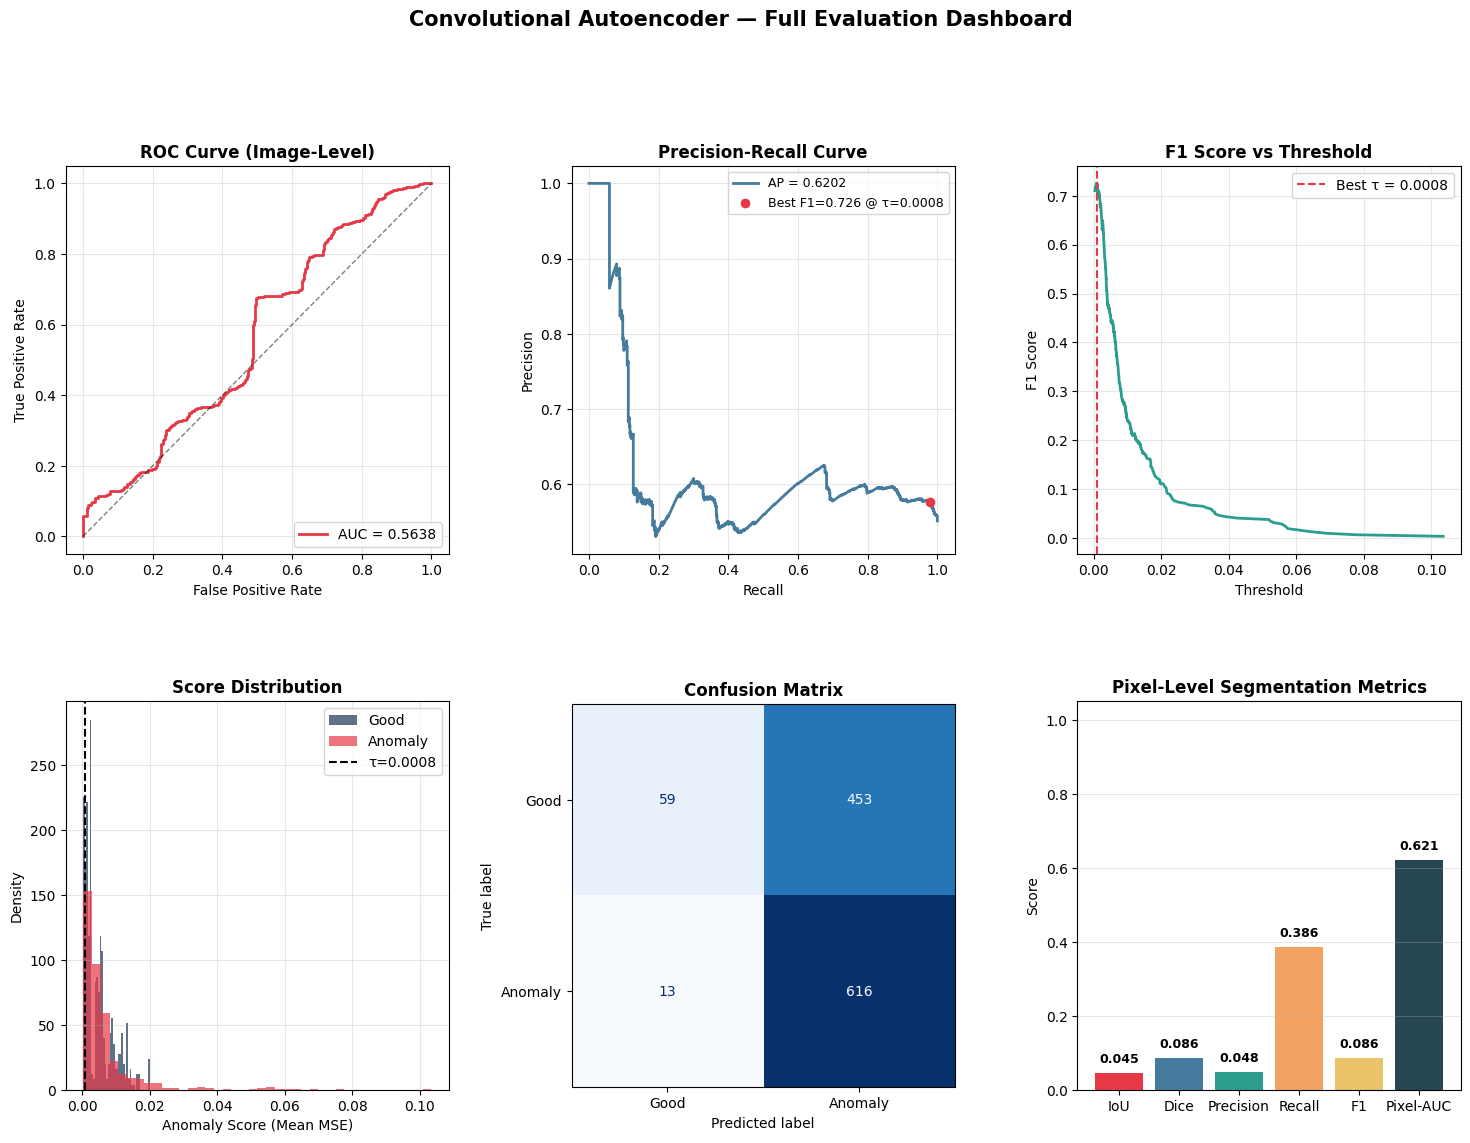


All plots saved → /kaggle/working/evaluation_dashboard.png


In [15]:
fpr, tpr, roc_thresholds = roc_curve(labels, scores)
image_auc = roc_auc_score(labels, scores)
print(f"Image-level ROC-AUC : {image_auc:.4f}")

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(labels, scores)
ap_score = average_precision_score(labels, scores)

f1_vals = np.where(
    (precision_vals + recall_vals) == 0, 0,
    2 * precision_vals * recall_vals / (precision_vals + recall_vals)
)
best_idx       = np.argmax(f1_vals[:-1])   # last element has no threshold
best_threshold = pr_thresholds[best_idx]
best_f1        = f1_vals[best_idx]
best_precision = precision_vals[best_idx]
best_recall    = recall_vals[best_idx]

print(f"Average Precision (AP)    : {ap_score:.4f}")
print(f"Best Threshold (max-F1)   : {best_threshold:.6f}")
print(f"  → Precision : {best_precision:.4f}")
print(f"  → Recall    : {best_recall:.4f}")
print(f"  → F1-Score  : {best_f1:.4f}\n")

preds = (scores >= best_threshold).astype(int)

print("=" * 45)
print("  Image-Level Classification Report")
print("=" * 45)
print(f"  {'Metric':<20} {'Good':>8} {'Anomaly':>10}")
print("-" * 45)
for cls_idx, cls_name in enumerate(["Good (0)", "Anomaly (1)"]):
    p = precision_score(labels, preds, pos_label=cls_idx, zero_division=0)
    r = recall_score(labels, preds, pos_label=cls_idx, zero_division=0)
    f = f1_score(labels, preds, pos_label=cls_idx, zero_division=0)
    print(f"  {cls_name:<20} P={p:.3f}  R={r:.3f}  F1={f:.3f}")
print("=" * 45)
overall_f1 = f1_score(labels, preds, average="weighted")
print(f"  Weighted F1  : {overall_f1:.4f}")
print(f"  Image AUC    : {image_auc:.4f}\n")

def otsu_threshold_np(error_map):
    """Compute Otsu threshold for a single 2D error map."""
    from skimage.filters import threshold_otsu
    try:
        return threshold_otsu(error_map)
    except Exception:
        return error_map.mean()


def compute_pixel_metrics(error_maps, image_labels, percentile=95):
    """
    Build pseudo pixel-GT masks and compare against
    binarised error maps.

    For anomaly images  → top-percentile of error map = defect GT
    For normal images   → GT mask is all zeros (no defect)
    """
    from skimage.filters import threshold_otsu

    pixel_preds_all = []
    pixel_gt_all    = []
    pixel_scores_all = []   # for pixel-AUC

    for i in range(len(error_maps)):
        emap = error_maps[i]                    # (H, W)
        norm_emap = (emap - emap.min()) / (emap.max() - emap.min() + 1e-8)

        # --- Predicted mask via Otsu on normalised error map ---
        try:
            otsu_th = threshold_otsu(norm_emap)
        except Exception:
            otsu_th = norm_emap.mean()
        pred_mask = (norm_emap >= otsu_th).astype(np.uint8)

        # --- Pseudo GT mask ---
        if image_labels[i] == 1:  # anomaly
            gt_th = np.percentile(norm_emap, percentile)
            gt_mask = (norm_emap >= gt_th).astype(np.uint8)
        else:                      # good
            gt_mask = np.zeros_like(pred_mask, dtype=np.uint8)

        pixel_preds_all.append(pred_mask.ravel())
        pixel_gt_all.append(gt_mask.ravel())
        pixel_scores_all.append(norm_emap.ravel())

    pixel_preds  = np.concatenate(pixel_preds_all)
    pixel_gt     = np.concatenate(pixel_gt_all)
    pixel_scores = np.concatenate(pixel_scores_all)

    # Metrics
    tp = ((pixel_preds == 1) & (pixel_gt == 1)).sum()
    fp = ((pixel_preds == 1) & (pixel_gt == 0)).sum()
    fn = ((pixel_preds == 0) & (pixel_gt == 1)).sum()
    tn = ((pixel_preds == 0) & (pixel_gt == 0)).sum()

    iou   = tp / (tp + fp + fn + 1e-8)
    dice  = 2 * tp / (2 * tp + fp + fn + 1e-8)
    prec  = tp / (tp + fp + 1e-8)
    rec   = tp / (tp + fn + 1e-8)
    f1    = 2 * prec * rec / (prec + rec + 1e-8)

    # Pixel-AUC (subsample for speed — 2M pixels)
    sample_idx = np.random.choice(len(pixel_scores), size=min(2_000_000, len(pixel_scores)), replace=False)
    try:
        pixel_auc = roc_auc_score(pixel_gt[sample_idx], pixel_scores[sample_idx])
    except Exception:
        pixel_auc = float("nan")

    return {
        "IoU"       : iou,
        "Dice"      : dice,
        "Precision" : prec,
        "Recall"    : rec,
        "F1"        : f1,
        "Pixel-AUC" : pixel_auc,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


pixel_metrics = compute_pixel_metrics(error_maps, labels)

print("=" * 40)
print("  Pixel-Level Segmentation Metrics")
print("=" * 40)
for k, v in pixel_metrics.items():
    if k not in ("TP", "FP", "FN", "TN"):
        print(f"  {k:<15} : {v:.4f}")
print("-" * 40)
print(f"  TP={pixel_metrics['TP']:,}  FP={pixel_metrics['FP']:,}  "
      f"FN={pixel_metrics['FN']:,}  TN={pixel_metrics['TN']:,}")
print("=" * 40)


# ============================================================
# 3.6  PLOTS — ROC, PR Curve, Confusion Matrix, Score Dist
# ============================================================

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# — ROC Curve —
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, color="#E63946", lw=2, label=f"AUC = {image_auc:.4f}")
ax1.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve (Image-Level)", fontweight="bold")
ax1.legend(loc="lower right"); ax1.grid(True, alpha=0.3)

# — PR Curve —
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(recall_vals, precision_vals, color="#457B9D", lw=2, label=f"AP = {ap_score:.4f}")
ax2.scatter(best_recall, best_precision, color="#E63946", zorder=5,
            label=f"Best F1={best_f1:.3f} @ τ={best_threshold:.4f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# — F1 vs Threshold —
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(pr_thresholds, f1_vals[:-1], color="#2A9D8F", lw=2)
ax3.axvline(best_threshold, color="#E63946", linestyle="--", lw=1.5,
            label=f"Best τ = {best_threshold:.4f}")
ax3.set_xlabel("Threshold"); ax3.set_ylabel("F1 Score")
ax3.set_title("F1 Score vs Threshold", fontweight="bold")
ax3.legend(); ax3.grid(True, alpha=0.3)

# — Anomaly Score Distribution —
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(scores[labels == 0], bins=40, alpha=0.7, color="#1D3557", label="Good",    density=True)
ax4.hist(scores[labels == 1], bins=40, alpha=0.7, color="#E63946", label="Anomaly", density=True)
ax4.axvline(best_threshold, color="black", linestyle="--", lw=1.5, label=f"τ={best_threshold:.4f}")
ax4.set_xlabel("Anomaly Score (Mean MSE)"); ax4.set_ylabel("Density")
ax4.set_title("Score Distribution", fontweight="bold")
ax4.legend(); ax4.grid(True, alpha=0.3)

# — Confusion Matrix —
ax5 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good", "Anomaly"])
disp.plot(ax=ax5, colorbar=False, cmap="Blues")
ax5.set_title("Confusion Matrix", fontweight="bold")

# — Pixel Metrics Bar Chart —
ax6 = fig.add_subplot(gs[1, 2])
pix_keys = ["IoU", "Dice", "Precision", "Recall", "F1", "Pixel-AUC"]
pix_vals = [pixel_metrics[k] for k in pix_keys]
bars = ax6.bar(pix_keys, pix_vals, color=["#E63946","#457B9D","#2A9D8F","#F4A261","#E9C46A","#264653"])
ax6.set_ylim(0, 1.05)
ax6.set_title("Pixel-Level Segmentation Metrics", fontweight="bold")
ax6.set_ylabel("Score"); ax6.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, pix_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Convolutional Autoencoder — Full Evaluation Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("/kaggle/working/evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll plots saved → /kaggle/working/evaluation_dashboard.png")
